In [1]:
import sys
import os

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.append(project_root)

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [2]:
from datapipeline.utils.spark_session import get_spark_session
spark = get_spark_session("Analytics_Dashboard")

In [14]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [15]:
analytics_base = os.path.join(project_root, "sanewsstorage/analytics")

topic_daily = spark.read.format("delta").load(os.path.join(analytics_base, "topic_daily"))
topic_realtime = spark.read.format("delta").load(os.path.join(analytics_base, "topic_realtime"))
event_snapshot = spark.read.format("delta").load(os.path.join(analytics_base, "event_snapshot"))
entity_daily = spark.read.format("delta").load(os.path.join(analytics_base, "entity_daily"))
search_index = spark.read.format("delta").load(os.path.join(analytics_base, "search_index"))

In [16]:
total_articles_24h = (
    topic_realtime
    .agg(F.sum("article_count_24h").alias("total"))
    .first()["total"] or 0
)

active_clusters = topic_realtime.count()
active_events = event_snapshot.count()

entity_24h_df = (
    entity_daily
    .filter(F.col("date") >= F.date_sub(F.current_date(), 1))
    .groupBy("entity_name")
    .agg(F.sum("mention_count").alias("mentions"))
    .orderBy(F.desc("mentions"))
    .limit(1)
)

entity_row = entity_24h_df.first()
top_entity_24h = entity_row["entity_name"] if entity_row else "No Data"

print("\n================ GLOBAL MEDIA OVERVIEW ================\n")
print(f"Total Articles (24h): {total_articles_24h}")
print(f"Active Clusters: {active_clusters}")
print(f"Active Events: {active_events}")
print(f"Top Entity (24h): {top_entity_24h}")
print("\n=======================================================\n")


================ GLOBAL MEDIA OVERVIEW ================

Total Articles (24h): 0
Active Clusters: 0
Active Events: 0
Top Entity (24h): No Data




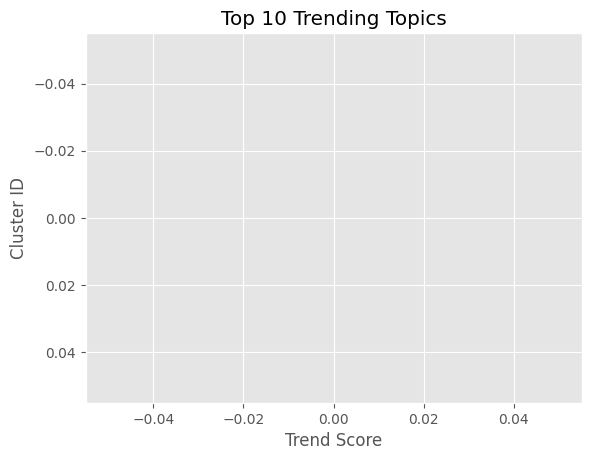

In [17]:
trend_panel = (
    topic_realtime
    .withColumn("rank", F.row_number().over(Window.orderBy(F.desc("trend_score"))))
    .orderBy("rank")
)

trend_pdf = (
    trend_panel
    .select("cluster_id", "trend_score")
    .limit(10)
    .toPandas()
)

plt.figure()
plt.barh(trend_pdf["cluster_id"].astype(str),
         trend_pdf["trend_score"])
plt.gca().invert_yaxis()
plt.title("Top 10 Trending Topics")
plt.xlabel("Trend Score")
plt.ylabel("Cluster ID")
plt.show()

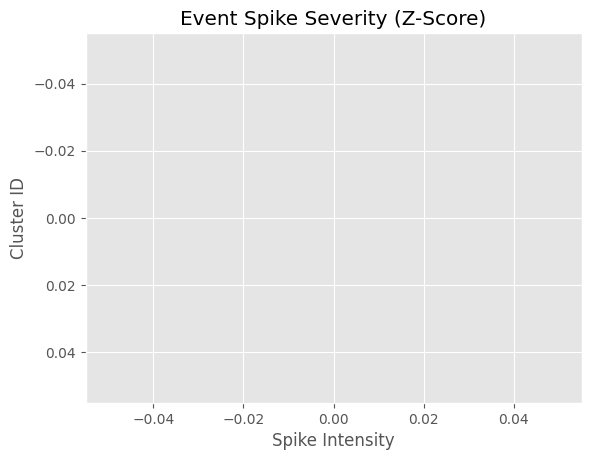

In [18]:
event_panel = (
    event_snapshot
    .withColumn("severity_rank",
                F.row_number().over(Window.orderBy(F.desc("z_score"))))
    .orderBy("severity_rank")
)

event_pdf = (
    event_panel
    .select("cluster_id", "z_score")
    .limit(10)
    .toPandas()
)

plt.figure()
plt.barh(event_pdf["cluster_id"].astype(str),
         event_pdf["z_score"])
plt.gca().invert_yaxis()
plt.title("Event Spike Severity (Z-Score)")
plt.xlabel("Spike Intensity")
plt.ylabel("Cluster ID")
plt.show()

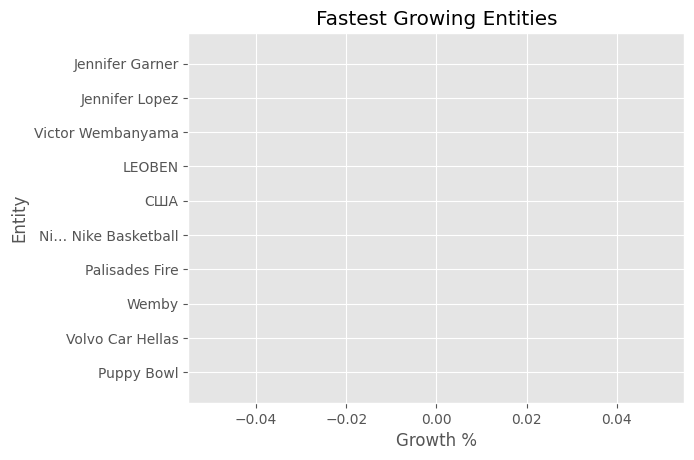

In [19]:
entity_growth = (
    entity_daily
    .groupBy("entity_name")
    .agg(
        F.sum(
            F.when(
                F.col("date") >= F.date_sub(F.current_date(), 1),
                F.col("mention_count")
            )
        ).alias("last_24h"),
        F.sum(
            F.when(
                F.col("date") >= F.date_sub(F.current_date(), 2),
                F.col("mention_count")
            )
        ).alias("last_48h")
    )
    .fillna(0)
    .withColumn(
        "growth_rate",
        F.when(F.col("last_48h") == 0, 0)
        .otherwise((F.col("last_24h") / F.col("last_48h")) * 100)
    )
    .orderBy(F.desc("growth_rate"))
)

entity_growth_pdf = (
    entity_growth
    .select("entity_name", "growth_rate")
    .limit(10)
    .toPandas()
)

plt.figure()
plt.barh(entity_growth_pdf["entity_name"],
         entity_growth_pdf["growth_rate"])
plt.gca().invert_yaxis()
plt.title("Fastest Growing Entities")
plt.xlabel("Growth %")
plt.ylabel("Entity")
plt.show()

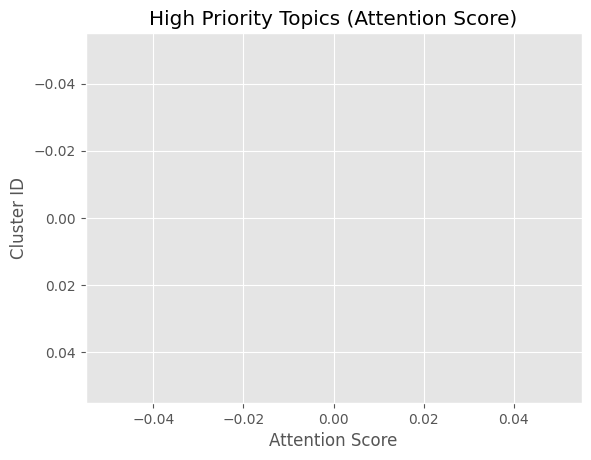

In [20]:
attention_df = (
    trend_panel
    .join(event_panel.select("cluster_id", "z_score"),
          on="cluster_id",
          how="left")
    .fillna(0)
    .withColumn(
        "attention_score",
        F.col("trend_score") * 0.6 +
        F.col("z_score") * 0.4
    )
    .orderBy(F.desc("attention_score"))
)

attention_pdf = (
    attention_df
    .select("cluster_id", "attention_score")
    .limit(10)
    .toPandas()
)

plt.figure()
plt.barh(attention_pdf["cluster_id"].astype(str),
         attention_pdf["attention_score"])
plt.gca().invert_yaxis()
plt.title("High Priority Topics (Attention Score)")
plt.xlabel("Attention Score")
plt.ylabel("Cluster ID")
plt.show()

In [21]:
def search_articles(keyword=None, cluster_id=None, date_from=None, date_to=None):

    df = search_index

    if keyword:
        df = df.filter(F.lower(F.col("title")).contains(keyword.lower()))

    if cluster_id:
        df = df.filter(F.col("cluster_id") == cluster_id)

    if date_from:
        df = df.filter(F.col("published_at") >= date_from)

    if date_to:
        df = df.filter(F.col("published_at") <= date_to)

    results = df.orderBy(F.desc("published_at")).limit(20).toPandas()

    print("\n================ SEARCH RESULTS ================\n")

    if results.empty:
        print("No results found.\n")
        return

    for _, row in results.iterrows():
        print(f"• {row['title']}")
        print(f"  Published: {row['published_at']}")
        print("-" * 60)

search_articles(keyword="ceasefire")


================ SEARCH RESULTS ================

• Israeli army kills Palestinian man east of Gaza City in violation of ceasefire
  Published: 2026-02-07 12:03:38
------------------------------------------------------------
• Hamas terrorists use ambulances, schools, hospitals in violation of US-brokered ceasefire, IDF official says
  Published: 2026-02-04 18:17:10
------------------------------------------------------------
• Israeli attacks kill hundreds in Gaza despite ceasefire, Health Ministry says
  Published: 2026-02-04 11:30:00
------------------------------------------------------------
• Israel Has Killed at Least 529 Palestinians in Gaza Since Signing Ceasefire Deal: Health Ministry - News From Antiwar.com
  Published: 2026-02-04 04:29:48
------------------------------------------------------------
• Syrian forces enter Qamishli under ceasefire deal with SDF: State media
  Published: 2026-02-03 19:10:32
------------------------------------------------------------
• Syrian 

In [22]:
spark.stop()